In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller,kpss
import yfinance as yf
import time

### Load data 

In [3]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

In [4]:
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB


In [6]:
df.describe()

,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [7]:
sns.set(style="whitegrid",palette="muted",rc ={"figure.figsize":(14,6)})

### Additional Time Parameters

In [8]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['Weekday'] = df.index.day_name()

In [9]:
df.head()

,Temp,Year,Month,Day,Weekday
Date,,,,,
1981-01-01,20.7,1981,1,1,Thursday
1981-01-02,17.9,1981,1,2,Friday
1981-01-03,18.8,1981,1,3,Saturday
1981-01-04,14.6,1981,1,4,Sunday
1981-01-05,15.8,1981,1,5,Monday


In [10]:
df.describe()

,Temp,Year,Month,Day
count,3650.000000,3650.000000,3650.000000,3650.000000
mean,11.177753,1985.500000,6.520548,15.719452
std,4.071837,2.872675,3.447566,8.795673
min,0.000000,1981.000000,1.000000,1.000000
25%,8.300000,1983.000000,4.000000,8.000000
50%,11.000000,1985.500000,7.000000,16.000000
75%,14.000000,1988.000000,10.000000,23.000000
max,26.300000,1990.000000,12.000000,31.000000


In [11]:
null_values= df.isnull().sum()
null_values

Temp       0
Year       0
Month      0
Day        0
Weekday    0
dtype: int64

### Time Series Plot

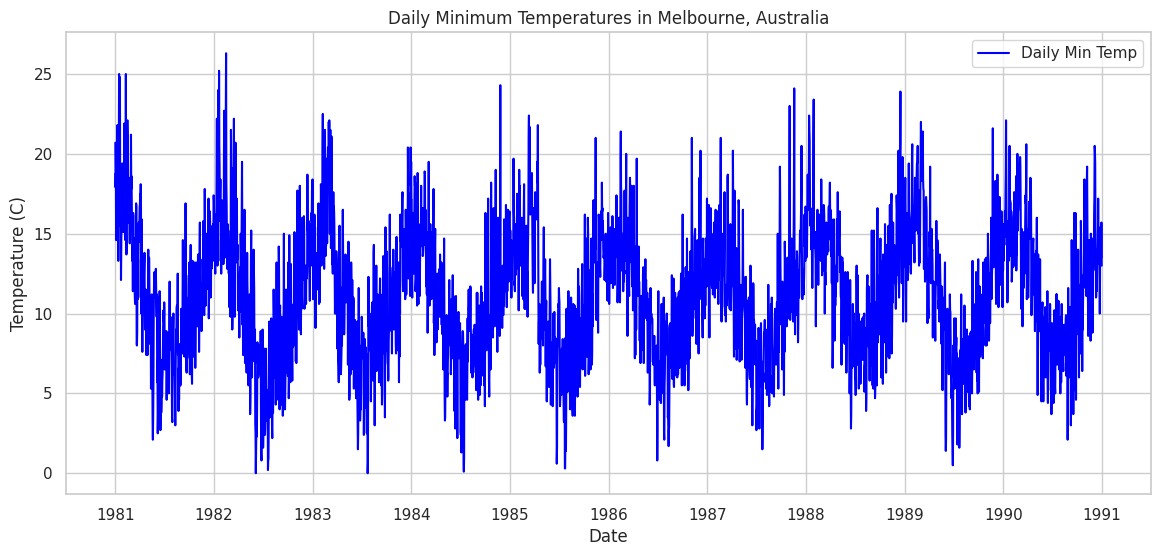

In [12]:
plt.figure()
plt.plot(df['Temp'],color='blue',label='Daily Min Temp')
plt.title('Daily Minimum Temperatures in Melbourne, Australia')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.legend()
plt.show()

### Distribution Analysis: Histogram & KDE

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


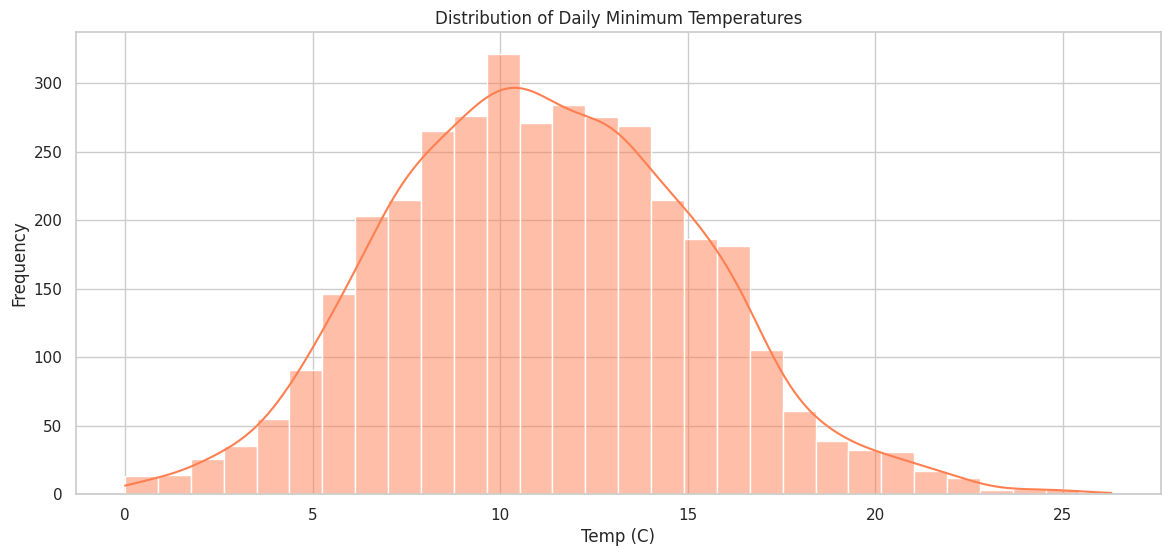

In [13]:
plt.figure()
sns.histplot(df['Temp'], bins = 30, kde = True, color='coral')
plt.title('Distribution of Daily Minimum Temperatures')
plt.xlabel('Temp (C)')
plt.ylabel('Frequency')
plt.show()

### Box Plot by Month to Visualize Seasonality

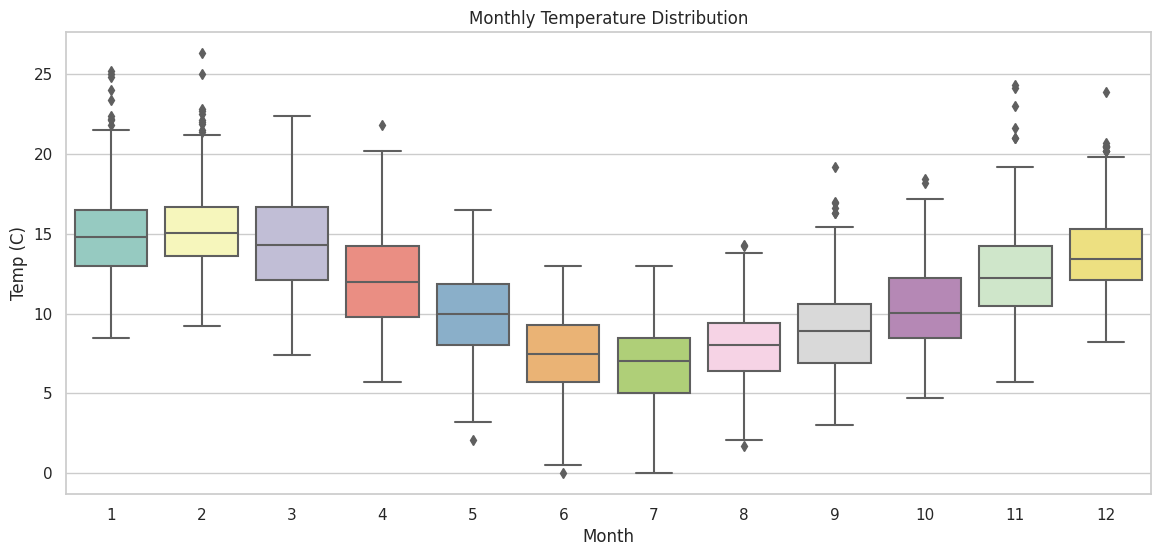

In [14]:
plt.figure()
sns.boxplot(x='Month', y = 'Temp', data=df, palette='Set3')
plt.title('Monthly Temperature Distribution')
plt.xlabel('Month')
plt.ylabel('Temp (C)')
plt.show()

### Seasonal Decomposition using STL

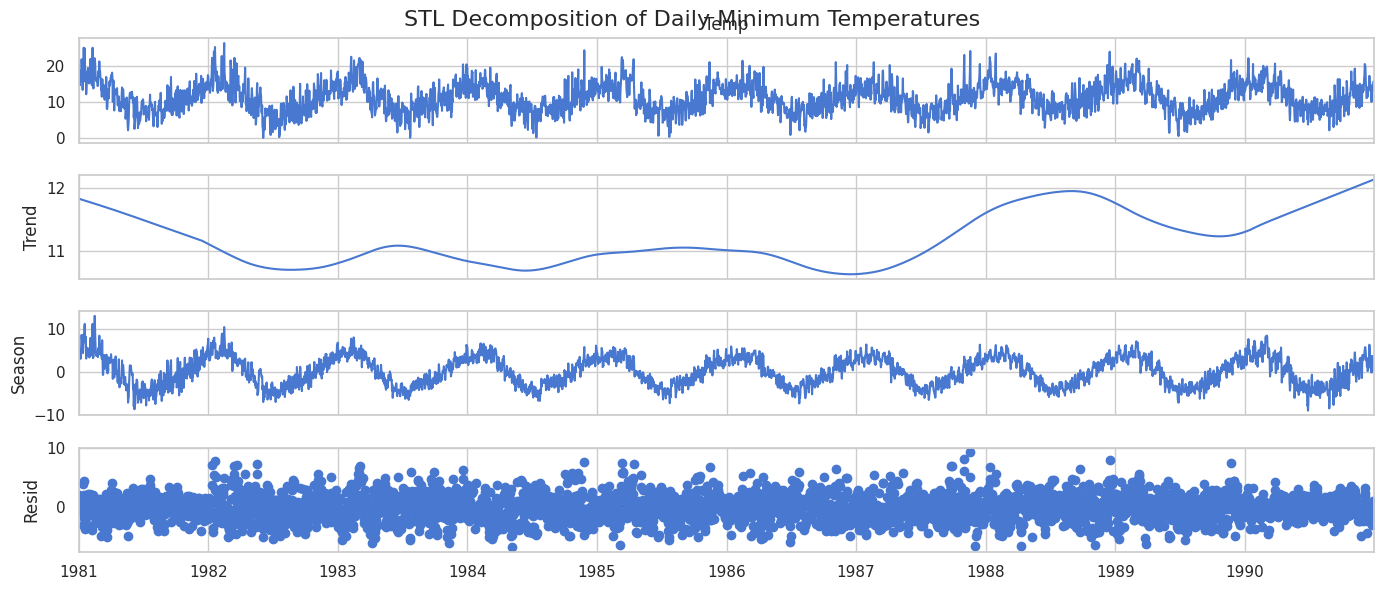

In [15]:
stl = STL(df['Temp'],period=365)
result = stl.fit()
result.plot()
plt.suptitle('STL Decomposition of Daily Minimum Temperatures', fontsize=16)
plt.show()

### Rolling Statistics: 30-day Rolling Mean & Std Dev

In [16]:
df['Rolling_Mean_30'] = df['Temp'].rolling(window=30).mean()
df['Rolling_Std_30'] = df['Temp'].rolling(window=30).std()

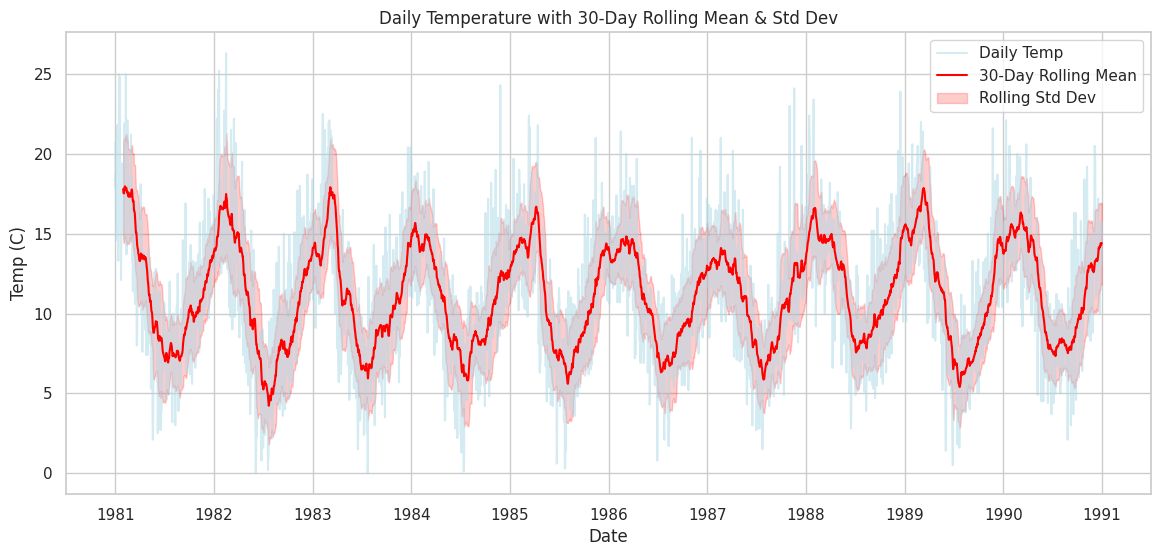

In [17]:
plt.figure()
plt.plot(df['Temp'], label = 'Daily Temp', color = 'lightblue',alpha=0.5)
plt.plot(df['Rolling_Mean_30'],label='30-Day Rolling Mean', color='red')
plt.fill_between(df.index,df['Rolling_Mean_30'] - df['Rolling_Std_30'],
                 df['Rolling_Mean_30'] + df['Rolling_Std_30'],
                 color='red', alpha=0.2, label='Rolling Std Dev')
plt.title('Daily Temperature with 30-Day Rolling Mean & Std Dev')
plt.xlabel('Date')
plt.ylabel('Temp (C)')
plt.legend()
plt.show()

### Autocorrelation and Partial Autocorrelation

<Figure size 1400x600 with 0 Axes>

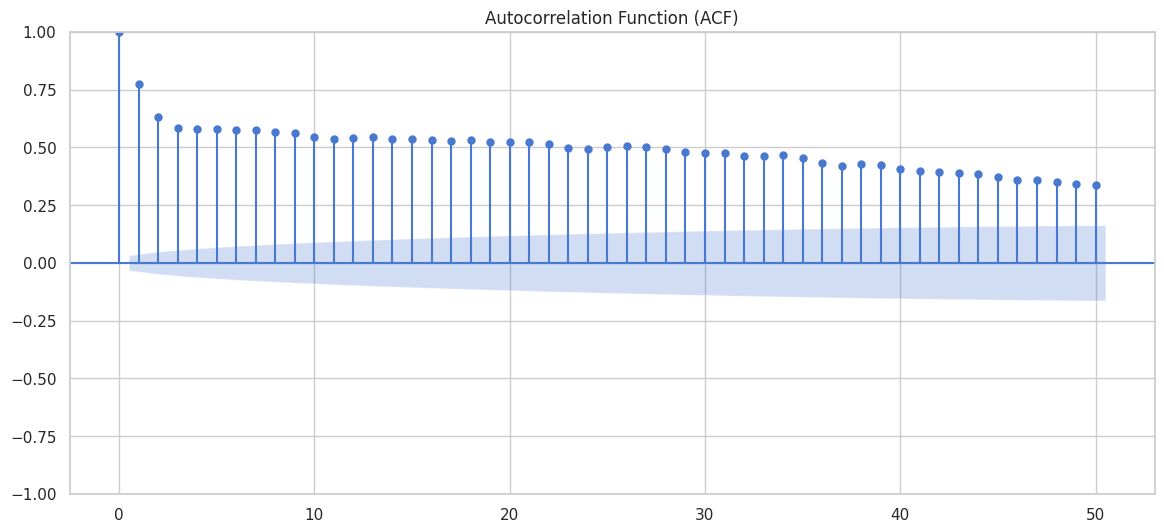

In [18]:
plt.figure()
plot_acf(df['Temp'].dropna(),lags=50)
plt.title("Autocorrelation Function (ACF)")
plt.show()

<Figure size 1400x600 with 0 Axes>

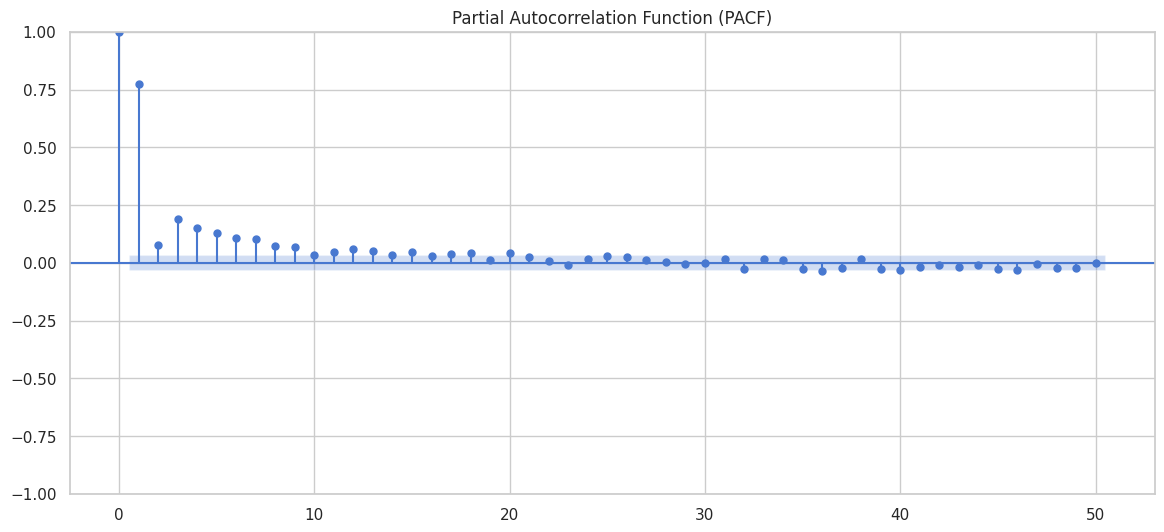

In [19]:
plt.figure()
plot_pacf(df['Temp'].dropna(),lags=50,method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

### Stationarity Tests: ADF and KPS

In [20]:
def stationarity_tests(ts):
    print("Augmented Dickey-Fuller Test:")
    adf_result = adfuller(ts.dropna())
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    print("Critical Values:")
    for key,value in adf_result[4].items():
        print(f" {key}:{value:.4f}")
    print("\nKPSS Test:")
    kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')
    print(f"KPSS Statistic: {kpss_result[0]:.4f}")
    print(f"p-value: {kpss_result[1]:.4f}")
    print("Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"   {key}: {value:.4f}")
print("Stationarity Tests for Daily Minimum Temperature:")
stationarity_tests(df['Temp'])

Stationarity Tests for Daily Minimum Temperature:
Augmented Dickey-Fuller Test:
ADF Statistic: -4.4448
p-value: 0.0002
Critical Values:
 1%:-3.4322
 5%:-2.8623
 10%:-2.5672

KPSS Test:
KPSS Statistic: 0.0557
p-value: 0.1000
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


<ipython-input-20-e4d954bf763c>:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')


### Seasonal Subseries Visualization: Average Temp by Month

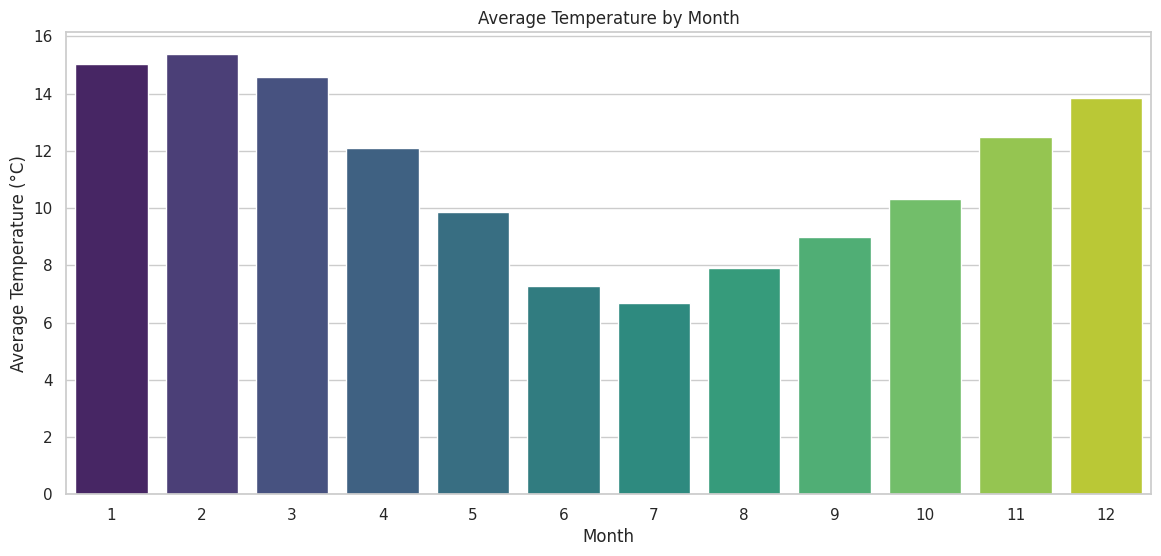

In [21]:
monthly_avg = df.groupby('Month')['Temp'].mean()
plt.figure()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values,palette='viridis')
plt.title('Average Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.show()

### Heatmap: Average Temperature by Year and Month

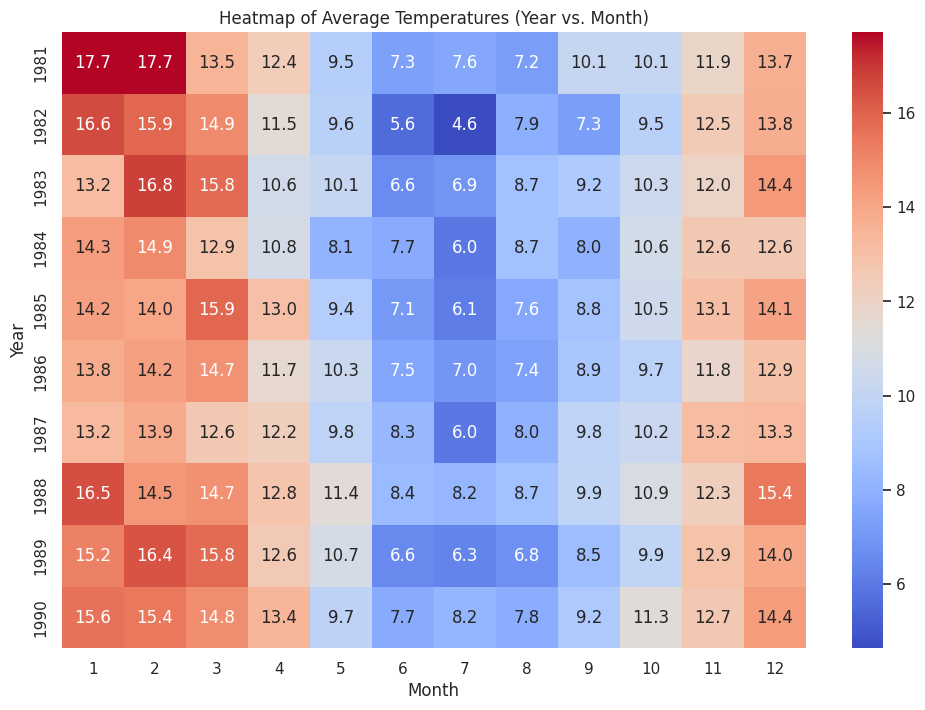

In [22]:
temp_pivot = df.pivot_table(values='Temp', index=df.index.year,columns='Month',aggfunc='mean')
plt.figure(figsize=(12,8))
sns.heatmap(temp_pivot, cmap='coolwarm', annot=True, fmt=".1f")
plt.title('Heatmap of Average Temperatures (Year vs. Month)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

### Detailed Explanation:

Loading & Basic Exploration:
We load the dataset from a public GitHub URL, parse the “Date” column into datetime format, and set it as the index. We then print out the head, info, and descriptive statistics so you can see the structure and overall numerical properties of the data.

Creating Time Parameters:
By extracting the year, month, day, and weekday from the datetime index, you enable richer analysis—such as grouping by month or day of the week—which is essential for exploring seasonal patterns.

Time Series Plot:
A simple line plot of daily minimum temperature shows the overall trend, fluctuations, and potential outliers over the entire period.

Distribution Analysis:
The histogram (with a KDE overlay) gives insight into the overall distribution of temperature values.

Box Plots by Month:
Creating box plots for each month helps visualize the spread and seasonal variation in temperatures.

Seasonal Decomposition (STL):
STL decomposition separates the time series into trend, seasonal, and residual components—providing clarity on the underlying structure.

Rolling Statistics:
Calculating a 30-day rolling mean and standard deviation helps smooth out short-term noise and highlights longer-term trends and volatility.

Autocorrelation Analysis:
ACF and PACF plots are produced to examine serial dependencies, which are important for forecasting and understanding lag effects.

Stationarity Tests:
The Augmented Dickey-Fuller (ADF) and KPSS tests help assess whether the time series is stationary—a key requirement for many time series forecasting models.

Seasonal Subseries and Heatmaps:
Bar plots and heatmaps visualize average temperature by month (and year), revealing seasonal cycles and potential long-term changes.

This detailed workflow covers a wide range of EDA techniques for time series data, allowing you to thoroughly explore and understand the dataset before moving on to modeling or forecasting tasks.